In [1]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian_2d(x, y, x0, y0, sigma):
    """Calculate the value of a 2D Gaussian at point (x, y) centered at (x0, y0) with standard deviation sigma."""
    return np.exp(-((x - x0) ** 2 + (y - y0) ** 2) / (2 * sigma ** 2))

def determine_grid_range(x_min, y_min, x_max, y_max, expansion_factor=0.4):
    """Determine the grid range by expanding the min/max by a given factor of the range."""
    # x_min, y_min = np.min(centers, axis=0)
    # x_max, y_max = np.max(centers, axis=0)
    
    # Calculate the range
    x_range = x_max - x_min
    y_range = y_max - y_min
    
    # Expand the range by the given factor
    x_min -= expansion_factor * x_range
    x_max += expansion_factor * x_range
    y_min -= expansion_factor * y_range
    y_max += expansion_factor * y_range
    
    return [x_min, x_max], [y_min, y_max]

def sum_gaussians(centers, x_range, y_range,  sigma, m):
    """Sum over Gaussians centered at given points and discretize into an m x m matrix."""
    # Create a grid of points within the specified range
    x = np.linspace(x_range[0], x_range[1], m)
    y = np.linspace(y_range[0], y_range[1], m)
    X, Y = np.meshgrid(x, y)
    
    # Initialize the matrix to store the sum of Gaussians
    Z = np.zeros((m, m))
    
    # Sum over each Gaussian centered at the given points
    for (x0, y0) in centers:
        Z += gaussian_2d(X, Y, x0, y0, sigma)
    
    return Z

In [2]:
import os
import torch
from torch_geometric.datasets import TUDataset

dataset = TUDataset(root='../data/TUDataset', name='PROTEINS')

print()
print(f'Dataset: {dataset}:')
print('====================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

data = dataset[20]  # Get the first graph object.

print()
print(data)
print('=============================================================')

# Gather some statistics about the first graph.
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree: {data.num_edges / data.num_nodes:.2f}')
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Has self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')


Dataset: PROTEINS(1113):
Number of graphs: 1113
Number of features: 3
Number of classes: 2

Data(edge_index=[2, 2024], x=[481, 3], y=[1])
Number of nodes: 481
Number of edges: 2024
Average node degree: 4.21
Has isolated nodes: False
Has self-loops: False
Is undirected: True


In [3]:
data['y']

tensor([0])

In [4]:
data['x']

tensor([[1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        ...,
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.]])

In [5]:
edge_sums = data['x'][data['edge_index'][0]] + data['x'][data['edge_index'][1]]
edge_sums.shape

torch.Size([2024, 3])

In [6]:
import sys
sys.path.append('/root/Codes/graph-mph0/build')
import abmph
import numpy as np

data = dataset[20] 
n_nodes = data.num_nodes
nodes = np.arange(0, n_nodes, dtype=int)
edges = data['edge_index'].reshape(-1, 2).numpy()
node_features = np.zeros(shape=(n_nodes, 2), dtype = np.float64)

# edge_features = np.random.randint(5, 10, size=(n_edges, 2)).astype(np.double)
edge_sums = data['x'][data['edge_index'][0]] + data['x'][data['edge_index'][1]]
edge_features = (edge_sums[:,[0,1]]).numpy().astype(np.float64)
# Create the Graph object
mph_g = abmph.Graph(nodes, node_features, edges, edge_features)
res_dt = abmph.compute_MPH0_DTree(mph_g)

In [7]:
b_0, b_1, b_2, b_0_1, M, em = abmph.compute_MPH0_DTree_CXX_debug(mph_g)

In [22]:
abmph.compute_MPH0_DTree_CXX_debug?

Docstring:
compute_MPH0_DTree_CXX_debug(arg0: abmph._abmph.Graph) -> tuple[list, list, list, list, list[tuple[int, int, int]], dict[str, list[tuple[int, int]]]]

Compute the absolute MPH0 by Dynamic Tree and return the results as a tuple of vectors and simplices matching.
Type:      builtin_function_or_method

In [8]:
em.keys()

dict_keys(['b_0_1', 'b_2', 'b_1'])

In [9]:
len(em['b_1']), len(b_1)

(949, 949)

In [10]:
len(em['b_2']), len(b_2)

(473, 473)

In [11]:
len(em['b_0_1']), len(b_0_1)

(1548, 1548)

In [12]:
np.array(em['b_2']).max()

2023

In [21]:
for i, (a, b) in enumerate(zip(em['b_2'], b_2)):
    if edge_features[a[0]][0] != b[0] or edge_features[a[1]][1] != b[1]:
        print(i, a, b)
        print(edge_features[a[0]][0], edge_features[a[1]][1])

for i, (a, b) in enumerate(zip(em['b_1'], b_1)):
    if edge_features[a[0]][0] != b[0] or edge_features[a[1]][1] != b[1]:
        print(i, a, b)
        print(edge_features[a[0]][0], edge_features[a[1]][1])

for i, (a, b) in enumerate(zip(em['b_0_1'], b_0_1)):
    if edge_features[a[0]][0] != b[0] or edge_features[a[1]][1] != b[1]:
        print(i, a, b)
        print(edge_features[a[0]][0], edge_features[a[1]][1])

In [9]:
import numpy as np
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [12]:
import sys
sys.path.append('/root/Codes/graph-mph0/build')
import abmph
import numpy as np
def compute_abs_mph0(input_graph):
    # set graph features
    n_nodes = input_graph.num_nodes
    nodes = np.arange(0, n_nodes, dtype=int)
    edges = input_graph['edge_index'].reshape(-1, 2).numpy()
    node_features = np.zeros(shape=(n_nodes, 2), dtype = np.float64)
    edge_sums = data['x'][data['edge_index'][0]] + data['x'][data['edge_index'][1]]
    edge_features = (edge_sums[:,[0,1]]).numpy().astype(np.double)
    print("max of edge_sums", edge_sums.max())
    # Create the Graph object
    mph_g = abmph.Graph(nodes, node_features, edges, edge_features)
    res = abmph.compute_MPH0_DTree(mph_g) 
    return res

In [13]:
def safe_concatenate(arr1, arr2):
    """
    Safely concatenate two 2D arrays, handling the case where one or both might be empty.
    """
    # Check if either array is empty
    if arr1.size == 0:
        return arr2  # Return arr2 if arr1 is empty
    elif arr2.size == 0:
        return arr1  # Return arr1 if arr2 is empty
    else:
        return np.concatenate((arr1, arr2), axis=0) 
    
abs_res = compute_abs_mph0(dataset[20])
b_1_arr = np.array(abs_res['b_1'])
b_2_arr = np.array(abs_res['b_2'])

b_arr = safe_concatenate(b_1_arr, b_2_arr)

In [14]:
from icecream import ic
bettis= []
labels = []

initial_center = compute_abs_mph0(dataset[0])['b_1'][0]
x_min, y_min = initial_center
x_max, y_max = initial_center

for i, graph in enumerate(dataset):
    labels.append(graph['y'].item())
    abs_res = compute_abs_mph0(graph)
    b_1_arr = np.array(abs_res['b_1'])
    b_2_arr = np.array(abs_res['b_2'])
    bettis.append([b_1_arr, b_2_arr])

    # Update min and max for x and y
    b_arr = safe_concatenate(b_1_arr, b_2_arr)
    if len(b_arr) == 0:
        continue
    x_min = min(x_min, np.min(b_arr[:, 0]))
    x_max = max(x_max, np.max(b_arr[:, 0]))
    y_min = min(y_min, np.min(b_arr[:, 1]))
    y_max = max(y_max, np.max(b_arr[:, 1]))
    if x_max > 1e5 or y_max > 1e5 or y_min < -1e5:
        print(i)
        print(x_max)
        print(y_max)
        print(y_min)
        break

labels = np.array(labels)

In [20]:
a2 = np.array(compute_abs_mph0(dataset[20])['b_2'])
a1 = np.array(compute_abs_mph0(dataset[20])['b_1'])
a1.shape, a1.dtype

((949, 2), dtype('float64'))

In [33]:
compute_abs_mph0(dataset[20]) == compute_abs_mph0(dataset[20]) 

(21,)

In [ ]:
np.sum(labels)

450

[-0.8, 2.8] [-0.8, 2.8]


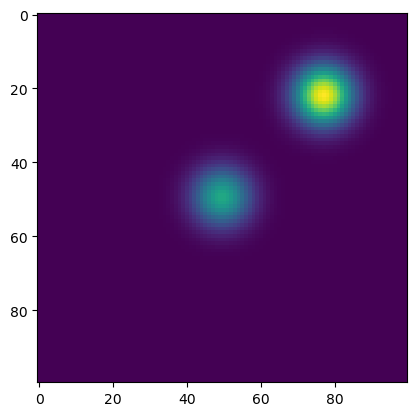

In [ ]:
imgs = []
sigma = 0.2  # Spread of the Gaussian
m = 100  # Size of the matrix
expansion_factor  = 0.4

# Determine the grid range automatically
x_range, y_range = determine_grid_range(x_min, y_min, 
                                        x_max, y_max,
                                        expansion_factor)
print(x_range, y_range)
centers = bettis[0][0]
Z = sum_gaussians(centers, x_range, y_range, sigma, m)
plt.imshow(Z)
for b_1, b_2 in bettis:
    centers1 = b_1
    centers2 = b_2
    # Compute the sum of Gaussians with automatic grid range determination
    Z1 = sum_gaussians(centers1, x_range, y_range, sigma, m)
    Z2 = sum_gaussians(centers2, x_range, y_range, sigma, m)
    imgs.append(Z1-Z2)

In [ ]:
imgs_array = np.array([img.flatten() for img in imgs])

In [ ]:
import numpy as np
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(imgs_array, labels, test_size=0.40, random_state=42)
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr.score(X_test, y_test)

0.7152466367713004

Final accuracy = 0.7152466367713004
ROC-AUC score = 0.7494824016563146


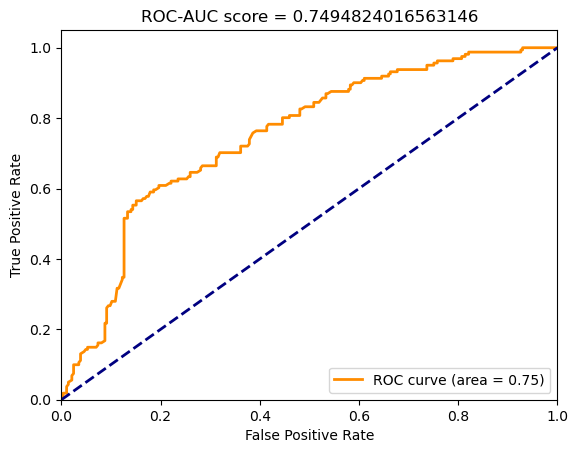

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
# Calculate accuracy
accuracy = lr.score(X_test, y_test)
print(f'Final accuracy = {accuracy}')

# Get predicted probabilities for the positive class
y_prob = lr.predict_proba(X_test)[:, 1]

# Calculate the ROC-AUC score
roc_auc = roc_auc_score(y_test, y_prob)
print(f'ROC-AUC score = {roc_auc}')

# Optional: Plotting the ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC-AUC score = {roc_auc}')
plt.legend(loc='lower right')
plt.show()